<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>


# Laboratorium nr 1: Sieci neuronowe - perceptron

## Perceptron
![perceptron](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/neuron2.PNG)![eq](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/n2eq2.PNG)

### Uczenie perceptronu
Uczenie perceptronu należy do grupy uczenia z nauczycielem i polega na takim doborze wektora wag $w$, aby sygnał wyjściowy neuronu $y$ były najbliżej wartości pożądanej $d$. Najpopularniejszą metodą uczenia perceptronu jest tzw. _reguła perceptronu_, którą można opisać w postaci kilku kroków.

Załóżmy, że dysponujemy zbiorem wektorów uczących postaci $\{x^{(0)}, x^{(1)}, \ldots, x^{(P)}\}$ oraz odpowiadającym mu zbiorem wartości pożądanych $\{d^{(0)}, d^{(1)},\ldots, d^{(P)}\}$.

#### Reguła perceptronu
1. Ustalamy $t = 0$.
2. Ustalamy w sposób losowy początkowe wartości wektora wag $w$.
3. Prezentujemy na wejścia perceptronu wektor uczący $x^{(t)}$.
4. Obliczamy odpowiedź perceptronu $y$ zgodnie z wzorem $y = g\left(\sum\limits_{i=0}^N{w_ix^{(t)}_i}\right)$, gdzie $g$ to fukcja skoku zwracająca $1$ gdy argument jest większy od $0$, a w przeciwnym wypadku $0$.
5. Porównujemy odpowiedź perceptronu $y$ z pożądaną odpowiedzią $d^{(t)}$.
6. Modyfikujemy wartości wag według poniższych reguł, parametr $\eta\in(0,1)$ to _współczynnuk uczenia_:
   - jeśli $y = d^{(t)}$ to wagi pozostają niezmienione,
   - jeśli $y = 0$, a $d^{(t)}=1$ to $w_i = w_i + \eta x_i^{(t)}$,
   - jeśli $y = 1$, a $d^{(t)}=0$ to $w_i = w_i - \eta x_i^{(t)}$.
7. Jeżeli warunek zatrzymania nie jest spełniony, to ustalamy $t = t + 1$ i wracamy do kroku 3, w przeciwnym przypadku kończymy algorytm.

Wykonanie powyższej procedury dla wszystkich wektorów uczących nazywamy _epoką uczenia_. W przypadku uczenia perceptronu wykonujemy tyle epok, aż wszystkie przykłady uczące będą dobrze sklasyfikowane lub błąd klasyfikacji będzie dostatecznie mały. Stabilność oraz szybkość uczenia tym algorytmem w istotny sposób zależy od doboru
parametru $\eta$. Współczynnik ten dobierany jest najczęściej w sposób empiryczny.

## Ćwiczenie 1:
Zaimplementuj model preceptronu w postaci klasy.

In [1]:
import numpy as np


class Perceptron:
    # Inicjalizator, ustawiający atrybut self.w oraz self.b jako wektor losowych wag, n ilość sygnałów wejściowych
    def __init__(self, n, bias=True):
        self.w = np.random.uniform(-0.1, 0.1, n)
        self.b = 0.0
        self.bias = bias

    # Metoda obliczająca odpowiedz modelu dla zadanego sygnału wejściowego x=[x1,x2,...,xN]
    def predict(self, x):
        x = np.asarray(x, dtype=float).ravel()
        activation = np.dot(self.w, x) + (self.b if self.bias else 0.0)
        return int(activation > 0)

    # Metoda uczenia według reguły perceptronu, xx - zbiór danych uczących, d - odpowiedzi,
    # eta - współczynnik uczenia,
    # tol - tolerancja (czyli jak duży błąd jesteśmy w stanie zaakceptować)
    def train(self, xx, d, eta, tol=0, maxepoch=10000, verbose=1):
        xx = np.asarray(xx, dtype=float)
        d = np.asarray(d).ravel().astype(int)

        for e in range(maxepoch):
            for x, di in zip(xx, d):
                y = self.predict(x)
                if y != di:
                    delta = eta * (di - y)
                    self.w = self.w + delta * x
                    if self.bias:
                        self.b = self.b + delta

            er, _ = self.evaluate_test(xx, d)

            if verbose:
                print(f"Epoka {e + 1}: liczba błędów = {er}")

            if er <= tol:
                break

        return self

    # Metoda obliczająca błąd dla danych testowych xx
    # zwraca błąd oraz wektor odpowiedzi perceptronu dla danych testowych
    def evaluate_test(self, xx, d=None):
        xx = np.asarray(xx, dtype=float)
        predictions = np.array([self.predict(x) for x in xx], dtype=int)

        if d is None:
            return predictions

        d = np.asarray(d).ravel().astype(int)
        er = int(np.sum(predictions != d))
        return er, predictions

    def confusion_matrix(self, xx, d):
        xx = np.asarray(xx, dtype=float)
        d = np.asarray(d).ravel().astype(int)
        predictions = self.evaluate_test(xx)

        tp = np.sum((predictions == 1) & (d == 1))
        tn = np.sum((predictions == 0) & (d == 0))
        fp = np.sum((predictions == 1) & (d == 0))
        fn = np.sum((predictions == 0) & (d == 1))

        return np.array([[tp, fp], [fn, tn]])

## Ćwiczenie 2:
- Stwórz dwa obiekty klasy `Perceptron`.
- Wczytaj dane z plików `2D.csv` oraz `3D.csv.`
- Pierwszy z perceptronów naucz klasyfikować dane z pliku `2D.csv`, ucz tylko na losowej części danych (np. 80%)
- Drugi z perceptronów naucz klasyfikować dane z pliku `3D.csv`, ucz tylko na losowej części danych (np. 80%)
- Oba zbiory danych są przykładami problemów liniowo separowalnych, a więc należy uczyć modele tak aby uzyskiwać dla danych uczących błąd równy zero.
- Przedstaw rezultaty uczenia na wykresach, odpowiednio 2D lub 3D. Na wykresach powinny znaleźć się dane testowe, tzn. te które nie były wykorzystywane w trakcie uczenia oraz linia (płaszczyzna) rozdzielająca klasy.

In [2]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "2D.csv", skiprows=1, delimiter=";", names=["X1", "X2", "L"], decimal=","
)
df2 = pd.read_csv(
    "3D.csv", skiprows=1, delimiter=";", names=["X1", "X2", "X3", "L"], decimal=","
)
df.head()

,X1,X2,L
0,-0.036819,-0.885263,0
1,-0.576998,-0.367745,1
2,0.397497,-0.418429,0
3,-0.288463,0.801790,1
4,0.829187,-0.350243,0


In [ ]:
from sklearn.model_selection import train_test_split
import plotly.express as px

px.scatter_3d(df2, x="X1", y="X2", z="X3", color="L")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["X1", "X2"]], df.drop(columns=["X1", "X2"]), test_size=0.2, random_state=42
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df2[["X1", "X2", "X3"]],
    df2.drop(columns=["X1", "X2", "X3"]),
    test_size=0.2,
    random_state=42,
)

In [6]:
X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]

(400, 100, 400, 100)

In [7]:
perceptron_df = Perceptron(2)
perceptron_df.train(xx=X_train, d=y_train, eta=0.5)

Epoka 1: liczba błędów = 2
Epoka 2: liczba błędów = 35
Epoka 3: liczba błędów = 7
Epoka 4: liczba błędów = 13
Epoka 5: liczba błędów = 17
Epoka 6: liczba błędów = 23
Epoka 7: liczba błędów = 10
Epoka 8: liczba błędów = 7
Epoka 9: liczba błędów = 2
Epoka 10: liczba błędów = 7
Epoka 11: liczba błędów = 8
Epoka 12: liczba błędów = 6
Epoka 13: liczba błędów = 6
Epoka 14: liczba błędów = 7
Epoka 15: liczba błędów = 6
Epoka 16: liczba błędów = 16
Epoka 17: liczba błędów = 17
Epoka 18: liczba błędów = 16
Epoka 19: liczba błędów = 19
Epoka 20: liczba błędów = 4
Epoka 21: liczba błędów = 1
Epoka 22: liczba błędów = 26
Epoka 23: liczba błędów = 6
Epoka 24: liczba błędów = 7
Epoka 25: liczba błędów = 5
Epoka 26: liczba błędów = 5
Epoka 27: liczba błędów = 5
Epoka 28: liczba błędów = 7
Epoka 29: liczba błędów = 8
Epoka 30: liczba błędów = 14
Epoka 31: liczba błędów = 16
Epoka 32: liczba błędów = 15
Epoka 33: liczba błędów = 17
Epoka 34: liczba błędów = 17
Epoka 35: liczba błędów = 7
Epoka 36: licz

In [8]:
perceptron_df2 = Perceptron(3)
perceptron_df2.train(xx=X_train2, d=y_train2, eta=0.5)

Epoka 1: liczba błędów = 31
Epoka 2: liczba błędów = 22
Epoka 3: liczba błędów = 24
Epoka 4: liczba błędów = 14
Epoka 5: liczba błędów = 16
Epoka 6: liczba błędów = 8
Epoka 7: liczba błędów = 15
Epoka 8: liczba błędów = 11
Epoka 9: liczba błędów = 14
Epoka 10: liczba błędów = 9
Epoka 11: liczba błędów = 7
Epoka 12: liczba błędów = 15
Epoka 13: liczba błędów = 3
Epoka 14: liczba błędów = 13
Epoka 15: liczba błędów = 18
Epoka 16: liczba błędów = 13
Epoka 17: liczba błędów = 12
Epoka 18: liczba błędów = 10
Epoka 19: liczba błędów = 12
Epoka 20: liczba błędów = 12
Epoka 21: liczba błędów = 8
Epoka 22: liczba błędów = 8
Epoka 23: liczba błędów = 10
Epoka 24: liczba błędów = 7
Epoka 25: liczba błędów = 5
Epoka 26: liczba błędów = 10
Epoka 27: liczba błędów = 13
Epoka 28: liczba błędów = 7
Epoka 29: liczba błędów = 2
Epoka 30: liczba błędów = 4
Epoka 31: liczba błędów = 10
Epoka 32: liczba błędów = 12
Epoka 33: liczba błędów = 13
Epoka 34: liczba błędów = 11
Epoka 35: liczba błędów = 13
Epoka

In [9]:
perceptron_df.w, perceptron_df.b

(array([-8.81289239,  4.40171146]), np.float64(3.5))

In [10]:
w2d, b2d = perceptron_df.w, perceptron_df.b
w3d, b3d = perceptron_df2.w, perceptron_df2.b

a = -w2d[0] / w2d[1]
c = -b2d / w2d[1]

a2 = -w3d[0] / w3d[2]
b2 = -w3d[1] / w3d[2]
c2 = -b3d / w3d[2]

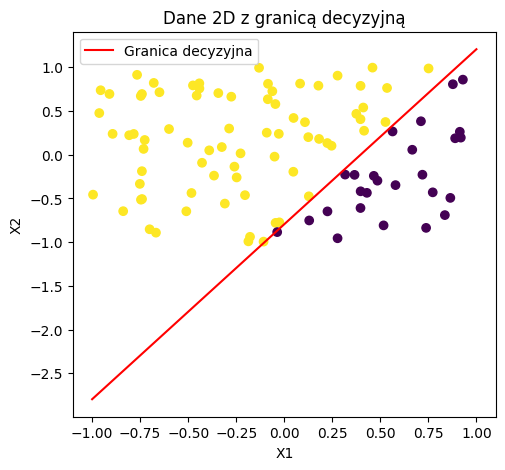

In [11]:
x = np.linspace(-1, 1, 10)
y = a * x + c
# test_sample = pd.concat([X_test, y_test], axis=1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_test["X1"], X_test["X2"], c=y_test["L"], cmap="viridis")
plt.plot(x, y, color="red", label="Granica decyzyjna")
plt.title("Dane 2D z granicą decyzyjną")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()

In [12]:
import plotly.graph_objects as go

x_plane = np.linspace(-1, 1, 30)
y_plane = np.linspace(-1, 1, 30)
X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
Z_plane = a2 * X_plane + b2 * Y_plane + c2

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=X_test2["X1"],
            y=X_test2["X2"],
            z=X_test2["X3"],
            mode="markers",
            marker=dict(
                size=5, color=y_test2["L"].values, colorscale="Viridis", opacity=0.8
            ),
            name="Dane testowe",
        ),
        go.Surface(
            x=X_plane, y=Y_plane, z=Z_plane, showscale=False, name="Granica decyzyjna"
        ),
    ]
)

fig.update_layout(
    title="Dane 3D z granicą decyzyjną",
    scene=dict(xaxis_title="X1", yaxis_title="X2", zaxis_title="X3"),
)
fig.show()

## Ćwiczenie 3:
Wybierz 2 dowolne klasy ze zbioru danych MNIST i wytrenuj model perceptronu do ich rozróżniania.

### Baza MNIST

- Baza MNIST zawiera zbiór trenujący składający się z 60,000 przykładów skanów ręcznie pisanych cyfr od 0 do 9 (problem klasyfikacyjny z 10 klasami).
- Zbiór testowy zawiera 10,000 przykładów.
- Każdy obraz ma rozmiar 28x28 pikseli. Stanowią one 28 * 28 = 784 wejść do sieci.
- W zagadnieniach rozpoznawania obrazów baza MNIST pełni rolę swoistego problemu `Hello world`.

#### Pobieranie bazy MNIST
- Najwygodniej jednak jest użyć bazy MNIST z wykorzystaniem biblioteki Keras

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2026-03-03 15:51:49.169809: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [14]:
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.mnist.load_data()
)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
train_images = np.expand_dims(train_images, axis=-1) / 255.0
train_labels = np.int64(train_labels)
test_images = np.expand_dims(test_images, axis=-1) / 255.0
test_labels = np.int64(test_labels)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


In [15]:
# Perceptron rozrozniajacy 2 i 7
train_filter = np.logical_or(train_labels == 2, train_labels == 7)
test_filter = np.logical_or(test_labels == 2, test_labels == 7)
X_train = train_images[train_filter].reshape(-1, 28 * 28)
y_train = (train_labels[train_filter] == 7).astype(int)
X_test = test_images[test_filter].reshape(-1, 28 * 28)
y_test = (test_labels[test_filter] == 7).astype(int)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(12223, 784) (12223,) (2060, 784) (2060,)


In [62]:
perceptron_mnist = Perceptron(X_train.shape[1])
perceptron_mnist.train(
    xx=X_train, d=y_train, eta=0.01, tol=200, maxepoch=1000, verbose=1
)

Epoka 1: liczba błędów = 191


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)

In [ ]:
err = (
    perceptron_mnist.confusion_matrix(X_val, y_val)[0, 1]
    + perceptron_mnist.confusion_matrix(X_val, y_val)[1, 0]
)
err

np.int64(20)

In [ ]:
err = X_val.shape[0]
while err > X_val.shape[0] * 0.015:
    perceptron_mnist = Perceptron(X_train.shape[1])
    perceptron_mnist.train(
        xx=X_train, d=y_train, eta=0.01, tol=110, maxepoch=1000, verbose=0
    )
    err = (
        perceptron_mnist.confusion_matrix(X_val, y_val)[0, 1]
        + perceptron_mnist.confusion_matrix(X_val, y_val)[1, 0]
    )
    print(f"Błąd: {err} / {X_val.shape[0]} ({err / X_val.shape[0]:.2%})")

Błąd: 18 / 1030 (1.75%)
Błąd: 19 / 1030 (1.84%)
Błąd: 21 / 1030 (2.04%)
Błąd: 21 / 1030 (2.04%)
Błąd: 17 / 1030 (1.65%)
Błąd: 20 / 1030 (1.94%)
Błąd: 17 / 1030 (1.65%)
Błąd: 22 / 1030 (2.14%)
Błąd: 18 / 1030 (1.75%)
Błąd: 22 / 1030 (2.14%)
Błąd: 21 / 1030 (2.04%)
Błąd: 20 / 1030 (1.94%)
Błąd: 23 / 1030 (2.23%)
Błąd: 18 / 1030 (1.75%)
Błąd: 19 / 1030 (1.84%)
Błąd: 21 / 1030 (2.04%)
Błąd: 21 / 1030 (2.04%)
Błąd: 17 / 1030 (1.65%)
Błąd: 20 / 1030 (1.94%)
Błąd: 17 / 1030 (1.65%)
Błąd: 18 / 1030 (1.75%)
Błąd: 18 / 1030 (1.75%)
Błąd: 15 / 1030 (1.46%)


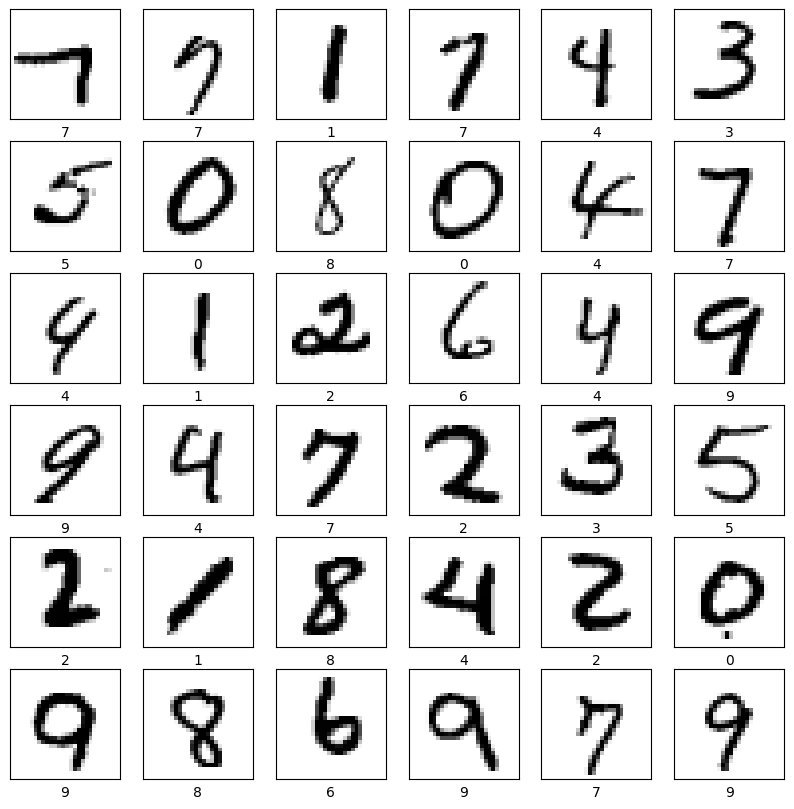

In [78]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

In [79]:
def check_png_2_7(nazwa):
    from pathlib import Path
    import cv2

    file_path = Path.cwd() / nazwa
    if not file_path.is_file():
        print(f"Plik {nazwa} nie istnieje.")
        return
    image = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Nie można wczytać obrazu {nazwa}")
        return
    plt.imshow(image, cmap="gray")
    image = cv2.resize(image, (28, 28))
    image = image.reshape(1, -1) / 255.0
    prediction = perceptron_mnist.predict(image)
    print(f"Predykcja dla obrazu '{nazwa}': {2 if prediction == 0 else 7}")

Predykcja dla obrazu 'dwapaint.png': 2


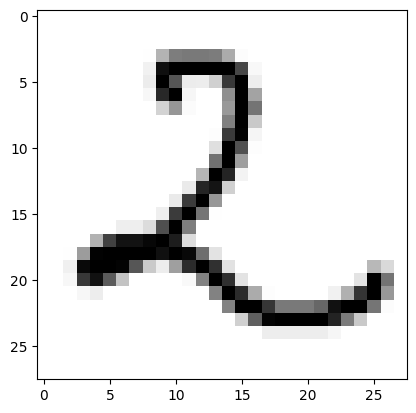

In [80]:
check_png_2_7("dwapaint.png")

Predykcja dla obrazu 'siedempaint.png': 2


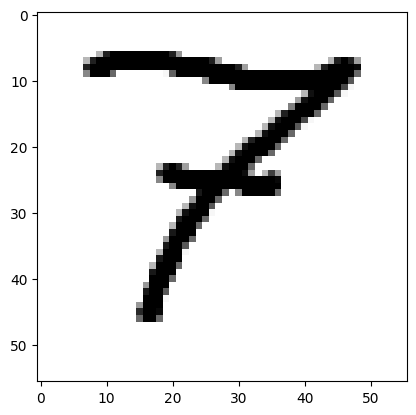

In [81]:
check_png_2_7("siedempaint.png")  # :(